## Augumentation


### Libraries

In [2]:
pip install tensorflow pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
pip install tensorflow-addons


   ---------------------------------------- 0.0/719.8 kB ? eta -:--:--
    --------------------------------------- 10.2/719.8 kB ? eta -:--:--
   - ------------------------------------- 30.7/719.8 kB 445.2 kB/s eta 0:00:02
   --- ----------------------------------- 71.7/719.8 kB 660.6 kB/s eta 0:00:01
   ------ ------------------------------- 122.9/719.8 kB 901.1 kB/s eta 0:00:01
   --------- ---------------------------- 174.1/719.8 kB 876.1 kB/s eta 0:00:01
   ------------ ------------------------- 235.5/719.8 kB 901.1 kB/s eta 0:00:01
   ----------------- ---------------------- 317.4/719.8 kB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 419.8/719.8 kB 1.2 MB/s eta 0:00:01
   ------------------------------ --------- 553.0/719.8 kB 1.4 MB/s eta 0:00:01
   ---------------------------------- ----- 614.4/719.8 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------  716.8/719.8 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 719.8/719.8 k


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, save_img, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


### Paths

In [2]:
INPUT_DIR = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\combined_dataset_split\train"
OUTPUT_DIR = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\augmented_dataset_only_train"

In [3]:
IMG_SIZE = (224, 224)
AUG_PER_IMAGE = 4  # number of augmented images per original image

### Augumentation Generator

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

In [5]:
for class_name in os.listdir(INPUT_DIR):
    os.makedirs(os.path.join(OUTPUT_DIR, class_name), exist_ok=True)

### Augument and Save Images 

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img

IMG_SIZE = (224, 224)

# Rotation layer (±20 degrees)
rotation_layer = tf.keras.layers.RandomRotation(
    factor=0.15,  # ~±27 degrees
    fill_mode="reflect"
)

for cls in os.listdir(INPUT_DIR):
    in_class = os.path.join(INPUT_DIR, cls)
    out_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(out_class, exist_ok=True)

    counter = 1

    for img_name in sorted(os.listdir(in_class)):
        img_path = os.path.join(in_class, img_name)

        img = load_img(img_path, target_size=IMG_SIZE)
        img = img_to_array(img) / 255.0

        # 1️⃣ Horizontal flip
        save_img(
            os.path.join(out_class, f"{cls}({counter})_flip_h.jpg"),
            tf.image.flip_left_right(img)
        )

        # 2️⃣ Vertical flip
        save_img(
            os.path.join(out_class, f"{cls}({counter})_flip_v.jpg"),
            tf.image.flip_up_down(img)
        )

        # 3️⃣ Rotation (NEW)
        img_batch = tf.expand_dims(img, axis=0)
        rotated = rotation_layer(img_batch, training=True)
        rotated = tf.squeeze(rotated, axis=0)
        save_img(
            os.path.join(out_class, f"{cls}({counter})_rotate.jpg"),
            rotated
        )

        # 4️⃣ Zoom in (central crop)
        zoom_in = tf.image.central_crop(img, central_fraction=0.8)
        zoom_in = tf.image.resize(zoom_in, IMG_SIZE)
        save_img(
            os.path.join(out_class, f"{cls}({counter})_zoom_in.jpg"),
            zoom_in
        )

        # 5️⃣ Zoom out (padding)
        zoom_out = tf.image.resize_with_pad(
            img,
            int(IMG_SIZE[0] * 0.8),
            int(IMG_SIZE[1] * 0.8)
        )
        zoom_out = tf.image.resize(zoom_out, IMG_SIZE)
        save_img(
            os.path.join(out_class, f"{cls}({counter})_zoom_out.jpg"),
            zoom_out
        )

        # 6️⃣ Brightness
        bright = tf.image.adjust_brightness(img, delta=0.2)
        save_img(
            os.path.join(out_class, f"{cls}({counter})_bright.jpg"),
            bright
        )

        counter += 1

print("✅ Traceable offline augmentation completed")



✅ Traceable offline augmentation completed


### Counting

In [7]:
import os

ORIGINAL = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\combined_dataset_split\train"
AUGMENTED = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\augmented_dataset_only_train"

def count_images(folder):
    total = 0
    class_counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        count = len(os.listdir(class_path))
        class_counts[class_name] = count
        total += count

    return total, class_counts


# Count originals
orig_total, orig_by_class = count_images(ORIGINAL)

# Count augmented
aug_total, aug_by_class = count_images(AUGMENTED)

print("\n===== DATA COUNT REPORT =====\n")

print("ORIGINAL DATASET:")
for k, v in orig_by_class.items():
    print(f"{k}: {v}")
print(f"TOTAL ORIGINAL IMAGES: {orig_total}\n")

print("AUGMENTED DATASET:")
for k, v in aug_by_class.items():
    print(f"{k}: {v}")
print(f"TOTAL AUGMENTED IMAGES: {aug_total}\n")

print("INCREASE IN DATA:")
print(f"New images added: {aug_total - orig_total}")

print("\nCOMBINED IMAGE COUNT:")
print(f"Total images: {aug_total + orig_total}")

print("\nAverage augmentation per image:",
      (aug_total - orig_total) / orig_total)




===== DATA COUNT REPORT =====

ORIGINAL DATASET:
Dry: 1904
Normal: 2292
Oily: 2150
TOTAL ORIGINAL IMAGES: 6346

AUGMENTED DATASET:
Dry: 11424
Normal: 13752
Oily: 12900
TOTAL AUGMENTED IMAGES: 38076

INCREASE IN DATA:
New images added: 31730

COMBINED IMAGE COUNT:
Total images: 44422

Average augmentation per image: 5.0


### Before and After Augmentation Dataset

Original dataset: {'dry': 409, 'normal': 492, 'oily': 461} Total: 1362
Augmented dataset: {'dry': 0, 'normal': 0, 'oily': 0} Total: 0


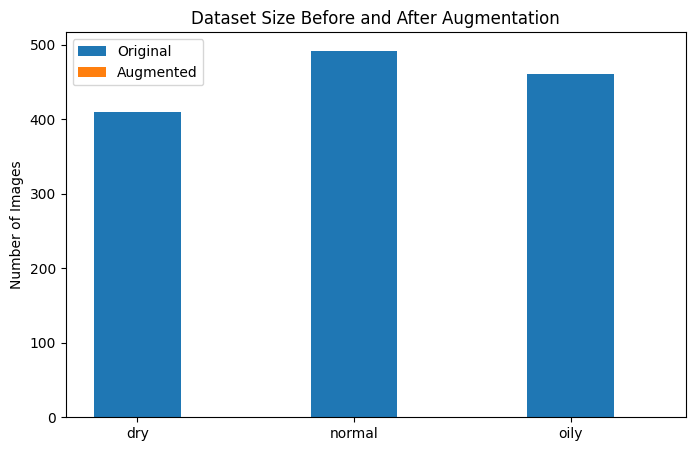

In [8]:
import os
import matplotlib.pyplot as plt

# Paths
original_dir = r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\combined_dataset_split\test"
augmented_dir =r"D:\Minor Project Related\Data Sets ( Oily, Dry , Normal )\ALL\Final Work\augmented_dataset"

classes = ["dry", "normal", "oily"]

# Function to count images per class
def count_images(folder):
    counts = {}
    for cls in classes:
        cls_path = os.path.join(folder, cls)
        if os.path.exists(cls_path):
            counts[cls] = len(os.listdir(cls_path))
        else:
            counts[cls] = 0
    return counts

# Count images
orig_counts = count_images(original_dir)
aug_counts = count_images(augmented_dir)

# Total images
total_orig = sum(orig_counts.values())
total_aug = sum(aug_counts.values())

print("Original dataset:", orig_counts, "Total:", total_orig)
print("Augmented dataset:", aug_counts, "Total:", total_aug)

# Plot
x = classes
orig_values = [orig_counts[cls] for cls in classes]
aug_values = [aug_counts[cls] for cls in classes]

plt.figure(figsize=(8,5))
plt.bar(x, orig_values, width=0.4, label="Original", align='center')
plt.bar(x, aug_values, width=0.4, label="Augmented", align='edge')
plt.ylabel("Number of Images")
plt.title("Dataset Size Before and After Augmentation")
plt.legend()
plt.show()
